In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm

import sys, os
sys.path.append(os.path.abspath("../src"))

from risk_metrics import historical_var, historical_es

In [3]:
# ETFs to analyze
tickers = [
    "SPY",   # S&P 500
    "QQQ",   # Nasdaq 100
    "IWM",   # Russell 2000
    "EEM",   # Emerging markets
    "TLT",   # long-term treasury bond
    "GLD"    # gold commodity
]

prices = yf.download(
    tickers,
    start="2015-01-01",
    end="2025-12-31",
    auto_adjust=True,
    progress=False
)["Close"]

log_returns = np.log(prices / prices.shift(1)).dropna()

print(prices.head())
print(log_returns.head())

Ticker            EEM         GLD         IWM        QQQ         SPY  \
Date                                                                   
2015-01-02  30.355045  114.080002  102.969826  94.784447  170.589584   
2015-01-05  29.814814  115.800003  101.593201  93.394089  167.508820   
2015-01-06  29.689531  117.120003   99.835594  92.141785  165.931030   
2015-01-07  30.331562  116.430000  101.065094  93.329597  167.998779   
2015-01-08  30.848312  115.940002  102.779343  95.115906  170.979935   

Ticker            TLT  
Date                   
2015-01-02  94.446419  
2015-01-05  95.930016  
2015-01-06  97.658401  
2015-01-07  97.465508  
2015-01-08  96.174797  
Ticker           EEM       GLD       IWM       QQQ       SPY       TLT
Date                                                                  
2015-01-05 -0.017957  0.014965 -0.013459 -0.014777 -0.018225  0.015586
2015-01-06 -0.004211  0.011334 -0.017452 -0.013500 -0.009464  0.017857
2015-01-07  0.021394 -0.005909  0.012240  0

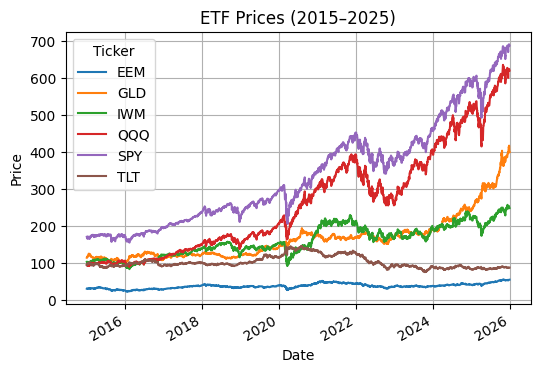

In [4]:
prices.plot(figsize=(6,4), title="ETF Prices (2015–2025)")
plt.ylabel("Price")
plt.grid(True)
plt.show()

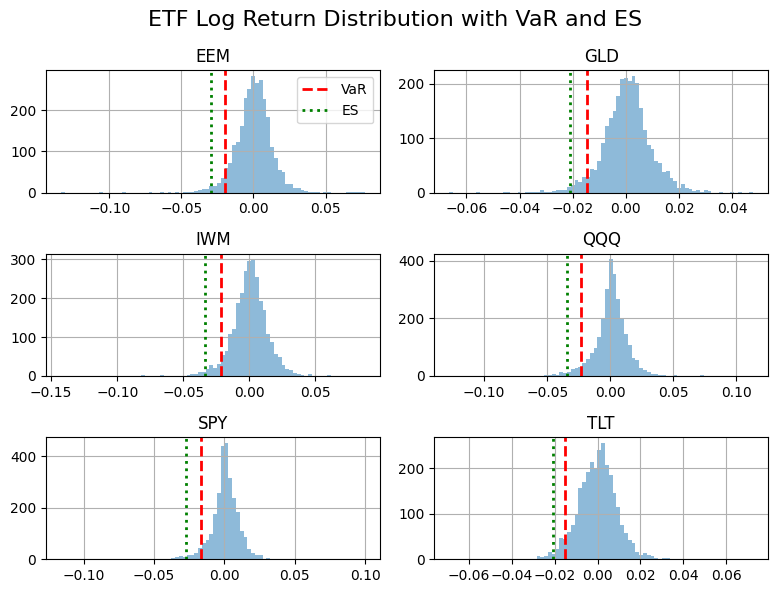

In [9]:
import matplotlib.pyplot as plt

alpha = 0.05

fig, axes = plt.subplots(3, 2, figsize=(8, 6))
axes = axes.flatten()

for i, col in enumerate(log_returns.columns):

    returns = log_returns[col].dropna()

    var = -historical_var(returns, alpha)
    es = -historical_es(returns, alpha)

    ax = axes[i]

    ax.hist(returns, bins=80, alpha=0.5)

    ax.axvline(var, linestyle="--", color='r', linewidth=2, label="VaR")
    ax.axvline(es, linestyle=":", color='g', linewidth=2, label="ES")

    ax.set_title(col)
    ax.grid(True)

fig.suptitle("ETF Log Return Distribution with VaR and ES", fontsize=16)

# show legend only once
axes[0].legend()

plt.tight_layout()
plt.show()

Portfolio Parametric VaR (95%): 0.0171
Portfolio Historical VaR (95%): 0.0164
Portfolio Parametric ES (95%): 0.0216
Portfolio Historical ES (95%): 0.0261


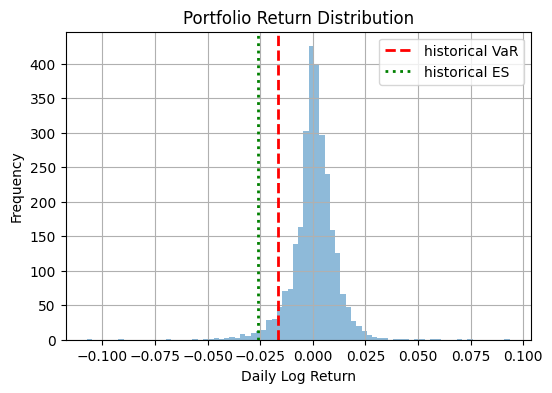

In [54]:
weights = np.array([0.5, 0.3, 0.05, 0.05, 0.05, 0.05])
portfolio_returns = log_returns[tickers].dot(weights)

k = 0.05
portfolio_var = historical_var(portfolio_returns, x)
portfolio_es  = historical_es(portfolio_returns, x)


# Portfolio mean and std
mu_p = portfolio_returns.mean()
sigma_p = portfolio_returns.std()

# the parametric VaR and ES
parametric_var = - (mu_p + sigma_p * norm.ppf(k))
parametric_es = - (mu_p - sigma_p * norm.pdf(norm.ppf(k)) / k)

# Historical VaR / ES
historical_var_val = historical_var(portfolio_returns.values, x=k)
historical_es_val = historical_es(portfolio_returns.values, x=k)

print(f"Portfolio Parametric VaR (95%): {parametric_var:.4f}")
print(f"Portfolio Historical VaR (95%): {historical_var_val:.4f}")
print(f"Portfolio Parametric ES (95%): {parametric_es:.4f}")
print(f"Portfolio Historical ES (95%): {historical_es_val:.4f}")


plt.figure(figsize=(6,4))

plt.hist(portfolio_returns, bins=80, alpha=0.5)

plt.axvline(-portfolio_var, linestyle="--", color='r', linewidth=2, label="historical VaR")
plt.axvline(-portfolio_es, linestyle=":", color='g', linewidth=2,  label="historical ES")

plt.title("Portfolio Return Distribution")
plt.xlabel("Daily Log Return")
plt.ylabel("Frequency")

plt.legend()
plt.grid(True)
plt.show()

In [45]:
window = 250
k = 0.05

rolling_var = portfolio_returns.rolling(window).apply(
    lambda x: historical_var(x, k),
    raw=True
)

rolling_es = portfolio_returns.rolling(window).apply(
    lambda x: historical_es(x, k),
    raw=True
)

rolling_var = rolling_var.dropna()
rolling_es = rolling_es.dropna()

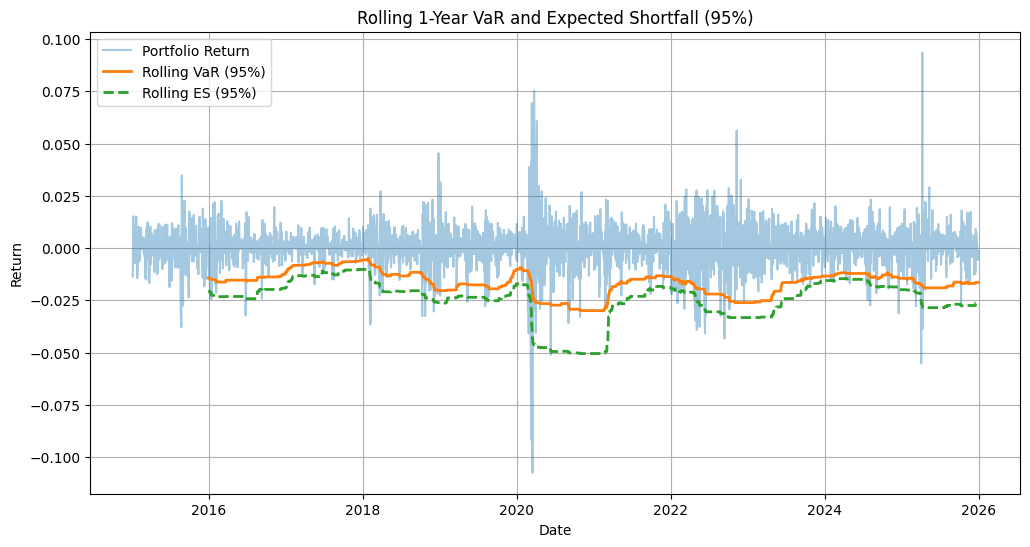

In [48]:
plt.figure(figsize=(12,6))

plt.plot(portfolio_returns.index, portfolio_returns,
         label="Portfolio Return", alpha=0.4)

plt.plot(rolling_var.index, -rolling_var,
         label="Rolling VaR (95%)", linewidth=2)

plt.plot(rolling_es.index, -rolling_es, linestyle='--',
         label="Rolling ES (95%)", linewidth=2)

plt.title("Rolling 1-Year VaR and Expected Shortfall (95%)")
plt.xlabel("Date")
plt.ylabel("Return")

plt.legend()
plt.grid(True)

plt.show()

In [55]:
# weights must be numpy array
weights = np.array([0.5, 0.3, 0.05, 0.05, 0.05, 0.05])
cov_matrix = log_returns.cov()  # covariance matrix of ETFs
sigma_p = np.sqrt(weights @ cov_matrix.values @ weights.T)

# Marginal contribution to portfolio std
marginal_std = cov_matrix.values @ weights / sigma_p

# Contribution to parametric VaR
marginal_var_contrib = marginal_std * norm.ppf(alpha) 

# Contribution in proportion to total portfolio VaR
prop_contrib = (weights * marginal_std * -norm.ppf(alpha)) / parametric_var

for ticker, contrib in zip(tickers, prop_contrib):
    print(f"{ticker}: {contrib:.2%} of portfolio parametric VaR")

SPY: 58.38% of portfolio parametric VaR
QQQ: 12.46% of portfolio parametric VaR
IWM: 4.89% of portfolio parametric VaR
EEM: 4.94% of portfolio parametric VaR
TLT: 4.14% of portfolio parametric VaR
GLD: 0.02% of portfolio parametric VaR


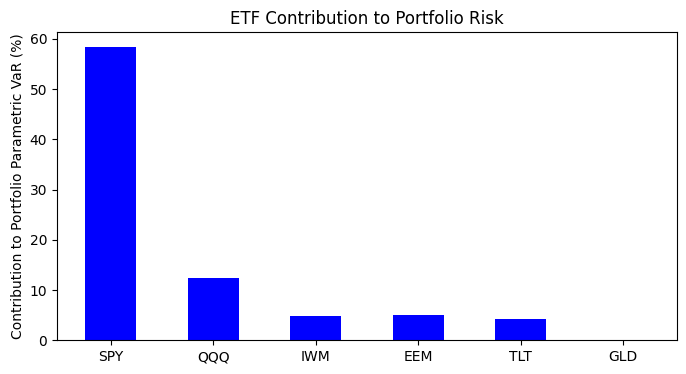

In [58]:
plt.figure(figsize=(8,4))
plt.bar(tickers, prop_contrib*100, color='blue', width=0.5)
plt.ylabel("Contribution to Portfolio Parametric VaR (%)")
plt.title("ETF Contribution to Portfolio Risk")
plt.show()